In [33]:
from tensorflow import keras
from keras import backend as K
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Dropout, BatchNormalization, Activation
from keras.models import Sequential
from keras.preprocessing.image import load_img

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [25]:
filenames = os.listdir("./train")

categories=[]

for filename in filenames:
    category = filename.split(".")[0]
    if category == "dog":
        categories.append(1)
    else:
        categories.append(0)
        
df=pd.DataFrame({
    "filename": filenames,
    "category": categories
})

In [10]:
df.head()

,filename,category
0,cat.0.jpg,0
1,cat.1.jpg,0
2,cat.10.jpg,0
3,cat.100.jpg,0
4,cat.1000.jpg,0


In [13]:
df["category"].value_counts()

0    12500
1    12500
Name: category, dtype: int64

<AxesSubplot:>

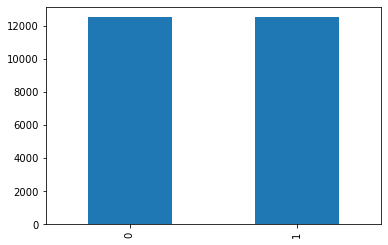

In [14]:
df["category"].value_counts().plot.bar()

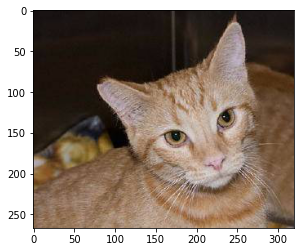

In [26]:
def show_image(label, file_id):
    filename=label+"."+file_id+".jpg"
    image=load_img("train/"+filename)
    plt.imshow(image)
    plt.show()
    
show_image("cat","14")

In [29]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation="relu", input_shape=(150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Dropout(.2))

model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Dropout(.2))

model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Dropout(.2))

model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Dropout(.2))

model.add(Flatten())
model.add(Dense(512, activation="relu"))
model.add(Dense(2,activation="softmax"))

model.compile(loss="categorical_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 74, 74, 32)       0         
 2D)                                                             
                                                                 
 batch_normalization_4 (Batc  (None, 74, 74, 32)       128       
 hNormalization)                                                 
                                                                 
 dropout_4 (Dropout)         (None, 74, 74, 32)        0         
                                                                 
 conv2d_5 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 36, 36, 64)      

In [30]:
df["category"] = df["category"].map({0:"cat",1:"dog"})

In [31]:
train_df, validation_df=train_test_split(df,test_size=0.20,random_state=42)
train_df=train_df.reset_index(drop=True)
validation_df=validation_df.reset_index(drop=True)

In [32]:
validation_df.head()

,filename,category
0,cat.493.jpg,cat
1,dog.9112.jpg,dog
2,cat.745.jpg,cat
3,dog.11022.jpg,dog
4,dog.11363.jpg,dog
